Goal is to see how the magnitude of an object after its mangled depends on the color difference between the input counts (with known spectra) and template used.

In [1]:
import numpy as np
import os
from utilities import *
import time
import pandas as pd

In [2]:
'''Finish function and clean up previous cells'''

'''take mangled photometry (magnitudes) and multiply by 0.07 redishift, subtract from original photometry (input)(magnitudes), this is k-correction. subtract two k corrections'''

def color_mag_difference(left_filter_index, right_filter_index, template_df):
    #structure of final arrays, first index is template being mangled, second is which other template was used as the input counts

    #mangled magnitude array which holds the magnitudes of a template after its been mangled
    #magnitude difference array which holds the difference in magnitudes of all six filters across all templates from before and after mangling,
    # this is possible since we actually have the spectra of all inputs, whereas in practice we only have the input counts
    #dimensions: # of templates, # of templates - 1
    mangled_mags = np.zeros((len(template_df['File Paths']), len(template_df["File Paths"]) - 1), dtype=object)
    mag_diff = np.zeros((len(template_df['File Paths']), len(template_df["File Paths"]) - 1), dtype=object)

    #array which holds color of every template after mangling
    #dimensions: # of templates, # of templates - 1
    mangled_colors = np.zeros((len(template_df['File Paths']), len(template_df["File Paths"]) - 1), dtype=object)

    #color difference array holding (M2-V)_initial - (M2-V)_mangled
    #dimensions: # of templates, # of templates - 1
    
    color_diff = np.zeros((len(template_df['File Paths']), len(template_df["File Paths"]) - 1), dtype=object)

    for i in range(len(template_df['File Paths']) - 1):
        print('processing template (', i+1, '/', len(template_df['File Paths'])-1, ')..')
        for j in range(len(template_df['File Paths']) - 1):
            #    confirm it gets zeroes on its own
            #if(i==j):
             #   mangled_mags[j,i] = np.zeros(6)
              #  mag_diff[j,i] = np.zeros(6)
               # mangled_colors[j,i] = 0
                #color_diff[j,i] = 0
                #continue
            # template i is input counts, j is the actual template
            results = np.zeros(4, dtype=object) #holds mangle results while in loop
            results = mangle_simple(np.array(template_df.loc[j,'Wavelengths']), 
                                    template_df.loc[j,'Flux'], 
                                    template_df.loc[j,'Filter Files'],
                                    template_df.loc[j,'Zero Points'],
                                    template_df.loc[j,'Pivot Wavelengths'],
                                    np.array(template_df.loc[i,'Counts']))
            #convert results to mangled mags
            #spectraWavelengths, mangledspectrumflux, temp_counts, speccounts_array
            mangled_mags[j,i] = countrates2mags_zeropoints(results[2], template_df.loc[j,'Zero Points'])
            mag_diff[j,i] = mangled_mags[j,i] - template_df.loc[i,'Magnitudes']
            mangled_colors[j,i] = (mangled_mags[j,i][1] - mangled_mags[j,i][5]) #uses predefined color as M2-V (should this be changed to choose any filter?)
            color_diff[j,i] = template_df.loc[i, 'Color'] - template_df.loc[j, 'Color'] # difference in color of mangled and orig
            
    #results[2], is the mangled flux
    return mangled_mags, mag_diff, mangled_colors, color_diff, results[2]

In [3]:
#intakes shifted magnitudes and fluxes
def mangle_z(num_temp, s_wave, s_flux, s_counts, filterfiles, zeropoints, pivots): #wrapper for calling mangle simple but with redshifting
    num_temp = len(s_wave)
    mangled_mags = np.zeros(num_temp, num_temp-1)
    for i in range(num_temp-1):
        print('processing shifted template (', i+1, '/', num_temp, ')..')
        for j in range(num_temp-1):
            if(i==j):
                mangled_mags[j,i] = np.zeros(6)
                #mag_diff[j,i] = np.zeros(6)
                continue
        results = np.zeros(4, dtype=object)
        results = mangle_simple(s_wave, s_flux, filterfiles, zeropoints, pivots, s_counts)
        mangled_mags[j,i] = countrates2mags_zeropoints(results[2], zeropoints)
    return mangled_mags

In [4]:
'''Finding counts from every template tested, takes ~3.5 min'''

#retreiving all template names
dir_list_2005 = os.listdir("../spectra/SN2005cs_modelspectra")
#remove non .fl files
dir_list_2005[:] = [i for i in dir_list_2005 if (i.endswith('.fl'))]
#add rest of file path
dir_list_2005 = ['SN2005cs_modelspectra/' + x for x in dir_list_2005]
        
#same process
dir_list_2006 = os.listdir("../spectra/SN2006bp_modelspectra")
dir_list_2006[:] = [i for i in dir_list_2006 if (i.endswith('.fl'))]
dir_list_2006 = ['SN2006bp_modelspectra/' + x for x in dir_list_2006]

#same process
dir_list_2011 = os.listdir("../spectra/SN2011fe_spectra")
dir_list_2011[:] = [i for i in dir_list_2011 if (i.endswith('.obs.dat'))]
dir_list_2011 = ['SN2011fe_spectra/' + x for x in dir_list_2011]

#make one big template array
dir_list = dir_list_2005 + dir_list_2006 + dir_list_2011

#gather info from desired filters and each template
filterfiles_list = []   #the proper files for each filter for each template
zeropoint_list = []     #zeropoints for each template
pivot_list = []         #wavelengths around which each template can be mangled
desired_filter_list = ['UVW2', 'UVM2','UVW1',  'U', 'B', 'V']
for i in dir_list:
    temp1, temp2, temp3 = filterlist_to_filterfiles(desired_filter_list, i)
    filterfiles_list.append(temp1)
    zeropoint_list.append(temp2)
    pivot_list.append(temp3)

#more info for every template
wavelength_list = []    #all wavelengths with an associated flux for each template
flux_list = []          #flux in each filter for each template
counts_array = []       #number of counts in each filter for each template
for i,j,z in zip(dir_list, filterfiles_list, range(1,len(dir_list)+1)):
    print('processing template (', z, '/', len(dir_list), ')..')
    temp1, temp2, temp3 = total_counts(i,j)
    wavelength_list.append(temp1)
    flux_list.append(temp2)
    counts_array.append(temp3)
print('counts calculated for all templates')


processing template ( 1 / 33 )..
processing template ( 2 / 33 )..
processing template ( 3 / 33 )..
processing template ( 4 / 33 )..
processing template ( 5 / 33 )..
processing template ( 6 / 33 )..
processing template ( 7 / 33 )..
processing template ( 8 / 33 )..
processing template ( 9 / 33 )..
processing template ( 10 / 33 )..
processing template ( 11 / 33 )..
processing template ( 12 / 33 )..
processing template ( 13 / 33 )..
processing template ( 14 / 33 )..
processing template ( 15 / 33 )..
processing template ( 16 / 33 )..
processing template ( 17 / 33 )..
processing template ( 18 / 33 )..
processing template ( 19 / 33 )..
processing template ( 20 / 33 )..
processing template ( 21 / 33 )..
processing template ( 22 / 33 )..
processing template ( 23 / 33 )..
processing template ( 24 / 33 )..
processing template ( 25 / 33 )..
processing template ( 26 / 33 )..
processing template ( 27 / 33 )..
processing template ( 28 / 33 )..
processing template ( 29 / 33 )..
processing template ( 3

In [5]:
#info we now have
#all templates:
# file paths                        dir_list
# filterfiles                       filterfiles_list
# zeropoints                        zeropoint_list
# pivot wavelengths                 pivot_list
# wavelength arrays                 wavelenth_list
# flux arrays                       flux_list
# total counts across all filters   counts_array

#now finding inital magnitudes of each template
magnitude_list = []
for i,j,z in zip(counts_array,zeropoint_list, range(len(counts_array))):
    magnitude_list.append(countrates2mags_zeropoints(i,j))

#finding initial colors as well (M2-V)
# this is predefined, doesn't change dependent on what filters we look at
color_list = []
for i in magnitude_list:
    color_list.append(i[1] - i[5])
    
#creating dataframe with all this info, named by dir_list
templates = {'File Paths':dir_list, 
             'Filter Files':filterfiles_list, 
             'Zero Points':zeropoint_list, 
             'Pivot Wavelengths':pivot_list,
             'Wavelengths': wavelength_list,
             'Flux':flux_list,
             'Counts': counts_array,
             'Magnitudes': magnitude_list,
             'Color': color_list}
templates = pd.DataFrame(templates)

#print(templates['Color'])

In [6]:
'''M2 - V'''
#structure of final arrays, first index is template being mangled, second is which other template was used as the input counts

#mangled magnitude array which holds the magnitudes of a template after its been mangled
#magnitude difference array which holds the difference in magnitudes of all six filters across all templates from before and after mangling,
# this is possible since we actually have the spectra of all inputs, whereas in practice we only have the input counts
#dimensions: # of templates, # of templates - 1
mangled_mags = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)
mag_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color array which holds M2-V color of every template after mangling
#dimensions: # of templates, # of templates - 1
mangled_colors = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color difference array holding (M2-V)_initial - (M2_V)_mangled
#dimensions: # of templates, # of templates - 1
color_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)
'''
#loop (i,j), which checks every template against ever other, once as the template proper, and once as the counts to be mangled
    #if i==j, skip loop
    
    #mangle template j given template i's counts
    #determine new mangs after mangling
    #determine new color
    #add mag diff to magnitude difference array
    #add color diff to color difference array
    
    #now repeat using template j as input and template i as template
    
    #mangle template i to j's counts
    #determine new mags
    #determine new color
    #add mag diff
    #add color diff
    
for i in range(len(templates['File Paths']) - 1):
    print('processing template (', i+1, '/', len(dir_list)-1, ')..')
    for j in range(len(templates['File Paths']) - 1): #change to same len as i loop once implemented
        if(i==j):
            mangled_mags[j,i] = np.zeros(6)
            mag_diff[j,i] = np.zeros(6)
            mangled_colors[j,i] = 0
            color_diff[j,i] = 0
            continue
        # template i is input counts, j is the actual template
        results = np.zeros(4, dtype=object) #holds mangle results while in loop
        results = mangle_simple(np.array(templates.loc[j,'Wavelengths']), 
                                templates.loc[j,'Flux'], 
                                templates.loc[j,'Filter Files'],
                                templates.loc[j,'Zero Points'],
                                templates.loc[j,'Pivot Wavelengths'],
                                np.array(templates.loc[i,'Counts']))
        #convert results to mangled mags
        #spectraWavelengths, mangledspectrumflux, temp_counts, speccounts_array
        mangled_mags[j,i] = countrates2mags_zeropoints(results[2], templates.loc[j,'Zero Points'])
        mag_diff[j,i] = mangled_mags[j,i] - templates.loc[i,'Magnitudes']
        #print("orig mag: \n", templates.loc[j,'Magnitudes'], "\nmangled mag: \n", mangled_mags[j,i])
        #print("difference: \n", mangled_mags[j,i] - templates.loc[j,'Magnitudes'])
        #print("difference again: \n", mag_diff[j,i])
        mangled_colors[j,i] = (mangled_mags[j,i][1] - mangled_mags[j,i][5]) #M2 - V
        #print(mangled_colors[j,i])
        #print(templates.loc[j,'Color'])
        color_diff[j,i] = templates.loc[i, 'Color'] - templates.loc[j, 'Color'] # difference in color of mangled and orig
'''
mangled_mags, mag_diff, mangled_colors, color_diff, mangled_flux = color_mag_difference(1,5,templates)

processing template ( 1 / 32 )..
processing template ( 2 / 32 )..
processing template ( 3 / 32 )..
processing template ( 4 / 32 )..
processing template ( 5 / 32 )..
processing template ( 6 / 32 )..
processing template ( 7 / 32 )..
processing template ( 8 / 32 )..
processing template ( 9 / 32 )..
processing template ( 10 / 32 )..
processing template ( 11 / 32 )..
processing template ( 12 / 32 )..
processing template ( 13 / 32 )..
processing template ( 14 / 32 )..
processing template ( 15 / 32 )..
processing template ( 16 / 32 )..
processing template ( 17 / 32 )..
processing template ( 18 / 32 )..
processing template ( 19 / 32 )..
processing template ( 20 / 32 )..
processing template ( 21 / 32 )..
processing template ( 22 / 32 )..
processing template ( 23 / 32 )..
processing template ( 24 / 32 )..
processing template ( 25 / 32 )..
processing template ( 26 / 32 )..
processing template ( 27 / 32 )..
processing template ( 28 / 32 )..
processing template ( 29 / 32 )..
processing template ( 3

In [7]:
'''
k-correction:

rest magnitude: magnitude at z=0

wavelength shift by lambda*(1+z)

flux by (1/1+z)

k_correct = rest_mag - obs_mag

rest_mag(wave,flux), obs_mag(wave(1+z), flux/(1+z))

k_correct of template with z = 0.07 - k_correct(input mangled to template)

take template we're mangling to, j, record its magnitudes, find shifted magnitudes by above factors and take their difference as seen w/ k_correct. This is done independent
of any mangling.

'''
#template red shifting
z1=0.07
input_mags = templates['Magnitudes'].to_numpy() 

#recalculating parameters for redshifting templates
shifted_wavelengths = []
shifted_flux = []
shifted_counts = []
for i,j,z in zip(dir_list, filterfiles_list, range(1,len(dir_list)+1)):
    print('shifting template (', z, '/', len(dir_list), ')..')
    temp1, temp2, temp3 = total_counts_z(i,j,z1)
    shifted_wavelengths.append(temp1)
    shifted_flux.append(temp2)
    shifted_counts.append(temp3)
shifted_mags = []
for i,j,z in zip(shifted_counts,zeropoint_list, range(len(shifted_counts))):
    shifted_mags.append(countrates2mags_zeropoints(i,j))

shifting template ( 1 / 33 )..
shifting template ( 2 / 33 )..
shifting template ( 3 / 33 )..
shifting template ( 4 / 33 )..
shifting template ( 5 / 33 )..
shifting template ( 6 / 33 )..
shifting template ( 7 / 33 )..
shifting template ( 8 / 33 )..
shifting template ( 9 / 33 )..
shifting template ( 10 / 33 )..
shifting template ( 11 / 33 )..
shifting template ( 12 / 33 )..
shifting template ( 13 / 33 )..
shifting template ( 14 / 33 )..
shifting template ( 15 / 33 )..
shifting template ( 16 / 33 )..
shifting template ( 17 / 33 )..
shifting template ( 18 / 33 )..
shifting template ( 19 / 33 )..
shifting template ( 20 / 33 )..
shifting template ( 21 / 33 )..
shifting template ( 22 / 33 )..
shifting template ( 23 / 33 )..
shifting template ( 24 / 33 )..
shifting template ( 25 / 33 )..
shifting template ( 26 / 33 )..
shifting template ( 27 / 33 )..
shifting template ( 28 / 33 )..
shifting template ( 29 / 33 )..
shifting template ( 30 / 33 )..
shifting template ( 31 / 33 )..
shifting template

In [8]:
k_template = []
for i in range(0,len(shifted_mags)):
    k_template.append((input_mags[i][0]-shifted_mags[i][0]))
print(k_template)
#print(input_mags.shape)
print(input_mags[5] - shifted_mags[5])
print(input_mags[5])

[array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944]), array([0.07345944])]
[[0.07345944]
 [0.07345944]
 [0.07345944]
 [0.07345944]
 [0.07345944]
 [0.07345944]]
[[-4.43019969]
 [-4.23900415]
 [-4.94361911]
 [-5.78884086]
 [-4.86162243]
 [-4.8835522 ]]


In [9]:
'''
Now take all our templates i and use them as input counts to j to find mangled magnitudes. This is our starting point. Now find the second k_correct by taking those mangled
mags and shifting them by the same factors above. Take this difference which is the second k_correct. 

At each pair of indicies j,i, we find the difference of k corrections as k_correct_1 - k_correct_2, where k_1 is for the template, and k_2 is from the template j using
template i's input

plotting x-axis color differnce of i-j, y-axis k difference of j - j,i

k_2 needs two indices since it depends both on the input and what template we're on
'''
#finding k-correction for mangled magnitudes
#already have mangled for unshifted templates
#now mangle shifted templates to get mangled shifted

#need to modify templates datafram with shifted paramaters
#replacing 
'''
    Wavelengths
    Flux
    Counts
    Magnitudes
    
    not replacing:
    File paths -not called
    Filter_files -same/not called
    Zeropoints -same
    Pivotwavelegths - similar
    Color - not called for this graph
'''
templates_shifted = templates
templates_shifted.Wavelengths = shifted_wavelengths
templates_shifted.Flux = shifted_flux
templates_shifted.Counts = shifted_counts
templates_shifted.Magnitudes = shifted_mags

mangled_mags_shifted, mag_diff_shifted, mangled_colors_shifted, color_diff_shifted, mangled_flux_shifted = color_mag_difference(1,5,templates_shifted)

processing template ( 1 / 32 )..
processing template ( 2 / 32 )..
processing template ( 3 / 32 )..
processing template ( 4 / 32 )..
processing template ( 5 / 32 )..
processing template ( 6 / 32 )..
processing template ( 7 / 32 )..
processing template ( 8 / 32 )..
processing template ( 9 / 32 )..
processing template ( 10 / 32 )..
processing template ( 11 / 32 )..
processing template ( 12 / 32 )..
processing template ( 13 / 32 )..
processing template ( 14 / 32 )..
processing template ( 15 / 32 )..
processing template ( 16 / 32 )..
processing template ( 17 / 32 )..
processing template ( 18 / 32 )..
processing template ( 19 / 32 )..
processing template ( 20 / 32 )..
processing template ( 21 / 32 )..
processing template ( 22 / 32 )..
processing template ( 23 / 32 )..
processing template ( 24 / 32 )..
processing template ( 25 / 32 )..
processing template ( 26 / 32 )..
processing template ( 27 / 32 )..
processing template ( 28 / 32 )..
processing template ( 29 / 32 )..
processing template ( 3

In [10]:
#unlike templates, the k-correction isn't the same across the 6 color filters
#for now, grabbing only the UVM2 mag, index 1
k_mangled = []
for i in range(0,len(mangled_mags)-1):
    for j in range(0,len(mangled_mags)-1):
        #print(i, j, type(mangled_mags[i][j]), type(mangled_mags_shifted[i][j]))
        temp = (mangled_mags[i][j][1]-mangled_mags_shifted[i][j][1])
        if(isinstance(temp,np.ndarray)):
            temp = temp[0]
        k_mangled.append(temp)
#print(k_mangled)
#print(mangled_mags_shifted[22][0])
#print(mangled_mags[0][0][1])

[np.float64(0.23358226486680778), np.float64(0.2577141555636757), np.float64(0.157330954234709), np.float64(0.15623011323634373), np.float64(0.14776670224826916), np.float64(0.22280755672714392), np.float64(0.2575739316976495), np.float64(0.25361678784765473), np.float64(0.2548403050460024), np.float64(0.16868706590896565), np.float64(0.15369609035090548), np.float64(0.24394643749302247), np.float64(0.24881836854194006), np.float64(0.15141366869462658), np.float64(0.24461958664357297), np.float64(0.15125092910046334), np.float64(0.15728867959794002), np.float64(0.24246038578205287), np.float64(0.19314076550788073), np.float64(0.14933843920003298), np.float64(0.1498059044911173), np.float64(0.2549225492538909), np.float64(0.2553555782167898), np.float64(0.1753309731331001), np.float64(0.19483632391912487), np.float64(0.1919978462692722), np.float64(0.1468730758480472), np.float64(0.15432144544203474), np.float64(0.18644933964528754), np.float64(0.18022773774916878), np.float64(0.1789613

In [11]:
#plotting k-corrections
k_correction = []
for i in range(len(k_template)):
    k_correction.append(k_template[i] - k_mangled[i])
print(k_correction)

[array([-0.16012282]), array([-0.18425471]), array([-0.08387151]), array([-0.08277067]), array([-0.07430726]), array([-0.14934811]), array([-0.18411449]), array([-0.18015734]), array([-0.18138086]), array([-0.09522762]), array([-0.08023665]), array([-0.17048699]), array([-0.17535892]), array([-0.07795422]), array([-0.17116014]), array([-0.07779148]), array([-0.08382924]), array([-0.16900094]), array([-0.11968132]), array([-0.07587899]), array([-0.07634646]), array([-0.18146311]), array([-0.18189613]), array([-0.10187153]), array([-0.12137688]), array([-0.1185384]), array([-0.07341363]), array([-0.080862]), array([-0.1129899]), array([-0.10676829]), array([-0.10550189]), array([-0.11315886]), array([0.12198261])]


In [12]:
#color diff again
color_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffm2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        color_diff2[j,i] = (templates.loc[j,'Color'][0]) - (templates.loc[i,'Color'][0])
        
        tempvalue = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
        mag_diff2[j,i] = tempvalue[0]
#        mag_diff2[j,i] = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
        tempvalue2 = mangled_mags[j,i][1] - templates.loc[i,'Magnitudes'][1]
        mag_diffm2[j,i] = tempvalue2[0]

0 0
[-5.29514176]
[-5.36860121]
[0.07345944]
1 0
[-5.28568608]
[-5.36860121]
[0.08291513]
2 0
[-5.31832]
[-5.36860121]
[0.0502812]
3 0
[-5.31863431]
[-5.36860121]
[0.04996689]
4 0
[-5.34246782]
[-5.36860121]
[0.02613339]
5 0
[-5.29798588]
[-5.36860121]
[0.07061533]
6 0
[-5.28557823]
[-5.36860121]
[0.08302298]
7 0
[-5.28946355]
[-5.36860121]
[0.07913765]
8 0
[-5.28338154]
[-5.36860121]
[0.08521967]
9 0
[-5.31211788]
[-5.36860121]
[0.05648333]
10 0
[-5.32338902]
[-5.36860121]
[0.04521218]
11 0
[-5.2927662]
[-5.36860121]
[0.07583501]
12 0
[-5.28013635]
[-5.36860121]
[0.08846486]
13 0
[-5.37363449]
[-5.36860121]
[-0.00503328]
14 0
[-5.27565701]
[-5.36860121]
[0.09294419]
15 0
[-5.3647888]
[-5.36860121]
[0.00381241]
16 0
[-5.31990313]
[-5.36860121]
[0.04869808]
17 0
[-5.29249621]
[-5.36860121]
[0.07610499]
18 0
[-5.30443012]
[-5.36860121]
[0.06417109]
19 0
[-5.35510567]
[-5.36860121]
[0.01349554]
20 0
[-5.34502349]
[-5.36860121]
[0.02357772]
21 0
[-5.2892523]
[-5.36860121]
[0.07934891]
22 0

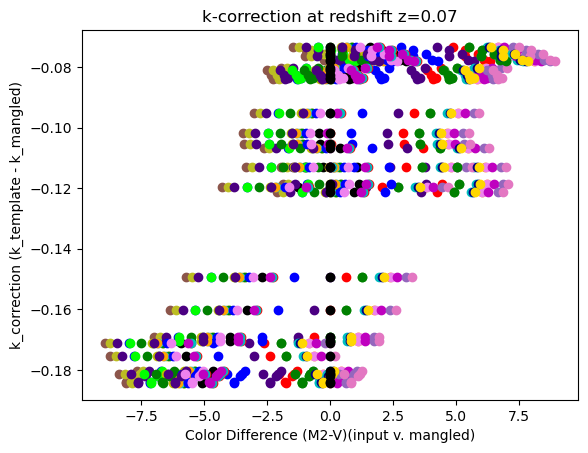

"\n    Check functions used, k_template shouldn't be constant across all 6 filters, effective areas of filters?\n"

In [13]:
color = ['r','orange','y','g','b','indigo', 'violet', 'c','m','k','tab:blue','tab:green','tab:purple', 'tab:brown','tab:pink','tab:olive','tab:cyan','g','b','indigo', 'lime','navy', 'gold','r','orange','y','g','b','indigo', 'violet', 'c','m','k','tab:blue','tab:green','tab:purple', 'tab:brown','tab:pink','tab:olive','tab:cyan','g','b','indigo', 'lime','navy', 'gold']
for i in range(len(mangled_mags)):
    for j in range(len(mangled_mags)-1):
        plt.scatter(color_diff[i,j], k_correction[j], c=color[i])

plt.xlabel("Color Difference (M2-V)(input v. mangled)")
plt.ylabel("k_correction (k_template - k_mangled)")
plt.title("k-correction at redshift z=0.07")

plt.show()

'''
    Check functions used, k_template shouldn't be constant across all 6 filters, effective areas of filters?
'''

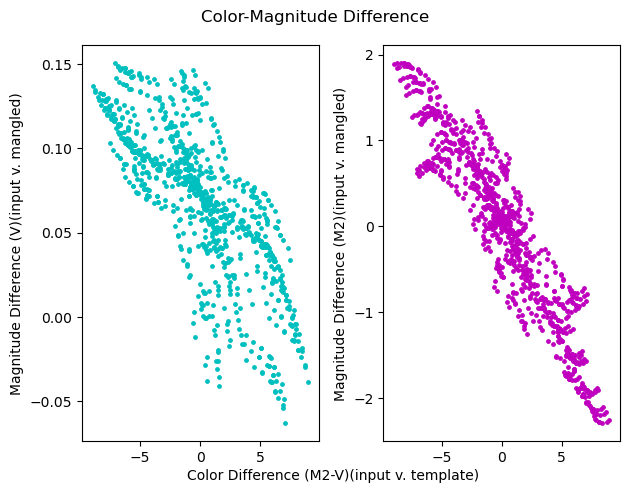

In [14]:
#plot results, color differnce of template and input v. magnitude difference of mangled mags and input mags
#j is template, i is input
color_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffm2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        color_diff2[j,i] = (templates.loc[j,'Color'][0]) - (templates.loc[i,'Color'][0])
        tempvalue3 = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
        mag_diff2[j,i] = tempvalue3[0]
        tempvalue4 = mangled_mags[j,i][1] - templates.loc[i,'Magnitudes'][1]
        mag_diffm2[j,i] = tempvalue4[0]

fig2, ax2 = plt.subplots(1,2, sharex=True)

for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax2[0].scatter(color_diff2[j,i], mag_diff2[j,i], c='c', s=6)
        ax2[1].scatter(color_diff[j,i], mag_diffm2[j,i], c='m', s=6)
        
fig2.suptitle("Color-Magnitude Difference")
fig2.text(0.3,0, 'Color Difference (M2-V)(input v. template)')
ax2[0].set_ylabel('Magnitude Difference (V)(input v. mangled)')
ax2[1].set_ylabel('Magnitude Difference (M2)(input v. mangled)')

plt.tight_layout()
plt.show()

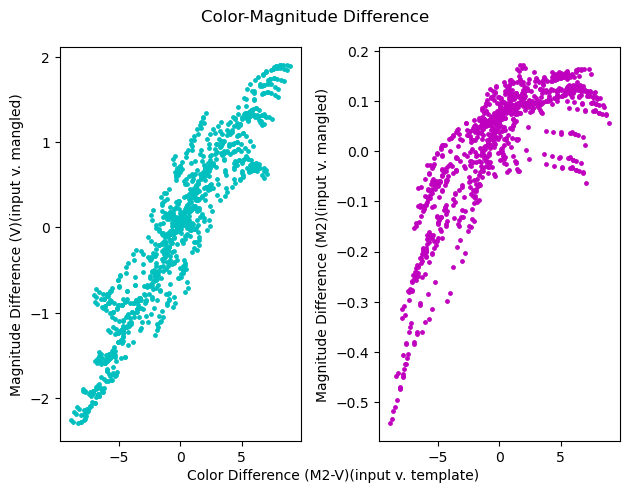

In [15]:
mag_diffw1 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffb = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        tempvalue4 = mangled_mags[j,i][4] - templates.loc[i,'Magnitudes'][4]
        mag_diffw1[j,i] =tempvalue4[0]
        tempvalue5 = mangled_mags[j,i][1] - templates.loc[i,'Magnitudes'][1]
        mag_diffb[j,i] = tempvalue5[0]

fig2, ax2 = plt.subplots(1,2, sharex=True)

for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax2[0].scatter(color_diff2[j,i], mag_diffb[j,i], c='c', s=6)
        ax2[1].scatter(color_diff[j,i], mag_diffw1[j,i], c='m', s=6)
        
fig2.suptitle("Color-Magnitude Difference")
fig2.text(0.3,0, 'Color Difference (M2-V)(input v. template)')
ax2[0].set_ylabel('Magnitude Difference (V)(input v. mangled)')
ax2[1].set_ylabel('Magnitude Difference (M2)(input v. mangled)')

plt.tight_layout()
plt.show()

In [16]:
'''W1-B'''
'''
#structure of final arrays, first index is template being mangled, second is which other template was used as the input counts

#mangled magnitude array which holds the magnitudes of a template after its been mangled
#magnitude difference array which holds the difference in magnitudes of all six filters across all templates from before and after mangling,
# this is possible since we actually have the spectra of all inputs, whereas in practice we only have the input counts
#dimensions: # of templates, # of templates - 1
mangled_mags = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)
mag_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color array which holds W1-B color of every template after mangling
#dimensions: # of templates, # of templates - 1
mangled_colors = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color difference array holding (W1-B)_initial - (W1-B)_mangled
#dimensions: # of templates, # of templates - 1
color_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

for i in range(len(templates['File Paths']) - 1):
    print('processing template (', i+1, '/', len(dir_list)-1, ')..')
    for j in range(len(templates['File Paths']) - 1): #change to same len as i loop once implemented
        if(i==j):
            mangled_mags[j,i] = np.zeros(6)
            mag_diff[j,i] = np.zeros(6)
            mangled_colors[j,i] = 0
            color_diff[j,i] = 0
            continue
        # template i is input counts, j is the actual template
        results = np.zeros(4, dtype=object) #holds mangle results while in loop
        results = mangle_simple(np.array(templates.loc[j,'Wavelengths']), 
                                templates.loc[j,'Flux'], 
                                templates.loc[j,'Filter Files'],
                                templates.loc[j,'Zero Points'],
                                templates.loc[j,'Pivot Wavelengths'],
                                np.array(templates.loc[i,'Counts']))
        #convert results to mangled mags
        #spectraWavelengths, mangledspectrumflux, temp_counts, speccounts_array
        mangled_mags[j,i] = countrates2mags_zeropoints(results[2], templates.loc[j,'Zero Points'])
        mag_diff[j,i] = mangled_mags[j,i] - templates.loc[i,'Magnitudes']
        mangled_colors[j,i] = (mangled_mags[j,i][2] - mangled_mags[j,i][4]) #W1 - B
        color_diff[j,i] = templates.loc[i, 'Color'] - templates.loc[j, 'Color'] # difference in color of mangled and orig
'''
mangled_mags, mag_diff, mangled_colors, color_diff, colordifresults = color_mag_difference(2,4,templates)


processing template ( 1 / 32 )..
processing template ( 2 / 32 )..
processing template ( 3 / 32 )..
processing template ( 4 / 32 )..
processing template ( 5 / 32 )..
processing template ( 6 / 32 )..
processing template ( 7 / 32 )..
processing template ( 8 / 32 )..
processing template ( 9 / 32 )..
processing template ( 10 / 32 )..
processing template ( 11 / 32 )..
processing template ( 12 / 32 )..
processing template ( 13 / 32 )..
processing template ( 14 / 32 )..
processing template ( 15 / 32 )..
processing template ( 16 / 32 )..
processing template ( 17 / 32 )..
processing template ( 18 / 32 )..
processing template ( 19 / 32 )..
processing template ( 20 / 32 )..
processing template ( 21 / 32 )..
processing template ( 22 / 32 )..
processing template ( 23 / 32 )..
processing template ( 24 / 32 )..
processing template ( 25 / 32 )..
processing template ( 26 / 32 )..
processing template ( 27 / 32 )..
processing template ( 28 / 32 )..
processing template ( 29 / 32 )..
processing template ( 3

In [17]:
#plot results, color differnce of template and input v. magnitude difference of mangled mags and input mags
#j is template, i is input
color_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffm2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        tempvalue7=(templates.loc[j,'Color'][0]) - (templates.loc[i,'Color'][0])
        color_diff2[j,i] = tempvalue7[0]
        tempvalue8 = mangled_mags[j,i][4] - templates.loc[i,'Magnitudes'][4]
        mag_diff2[j,i] = tempvalue8[0]
        tempvalue9 = mangled_mags[j,i][2] - templates.loc[i,'Magnitudes'][2]
        mag_diffm2[j,i] = tempvalue9[0]

IndexError: invalid index to scalar variable.

In [ ]:
fig2, ax2 = plt.subplots(1,2, sharex=True)

for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax2[0].scatter(color_diff2[j,i], mag_diff2[j,i], c='c', s=6)
        ax2[1].scatter(color_diff[j,i], mag_diffm2[j,i], c='m', s=6)
        
fig2.suptitle("Color-Magnitude Difference")
fig2.text(0.3,0, 'Color Difference (M2-V)(input v. template)')
ax2[0].set_ylabel('Magnitude Difference (B)(input v. mangled)')
ax2[1].set_ylabel('Magnitude Difference (W1)(input v. mangled)')

plt.tight_layout()
plt.show()

In [ ]:
'''B-V'''
mangled_mags, mag_diff, mangled_colors, color_diff = color_mag_difference(4,5,templates)

In [ ]:
#plot results, color differnce of template and input v. magnitude difference of mangled mags and input mags
#j is template, i is input
color_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffm2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        tempvalue11= (templates.loc[j,'Color'][0]) - (templates.loc[i,'Color'][0])
        color_diff2[j,i] = tempvalue11[0]
        tempvalue12 = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
        mag_diff2[j,i] = tempvalue12[0]
        tempvalue13 = mangled_mags[j,i][4] - templates.loc[i,'Magnitudes'][4]
        mag_diffm2[j,i] = tempvalue13[0]
        
fig2, ax2 = plt.subplots(1,2, sharex=True)

for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax2[0].scatter(color_diff2[j,i], mag_diff2[j,i], c='c', s=6)
        ax2[1].scatter(color_diff[j,i], mag_diffm2[j,i], c='m', s=6)
        
fig2.suptitle("Color-Magnitude Difference")
fig2.text(0.3,0, 'Color Difference (M2-V)(input v. template)')
ax2[0].set_ylabel('Magnitude Difference (V)(input v. mangled)')
ax2[1].set_ylabel('Magnitude Difference (B)(input v. mangled)')

plt.tight_layout()
plt.show()